# Exemplo: Engenharia de variáveis
------------------------------

Este exemplo mostra como usar geração automática de variáveis para melhorar o desempenho de um modelo.

Os dados utilizados são uma variação do [conjunto de dados de clima australiano](https://www.kaggle.com/jsphyg/weather-dataset-rattle-package) do Kaggle. Você pode baixá-lo [aqui](https://github.com/tvdboom/ExperionML/blob/master/examples/datasets/weatherAUS.csv). O objetivo deste conjunto é prever se vai chover amanhã treinando um classificador binário com a variável alvo `RainTomorrow`.

## Carregar os dados

In [1]:
# Import packages
import pandas as pd
from experionml import ExperionMLClassifier

In [2]:
# Carregue os dados
X = pd.read_csv("./datasets/weatherAUS.csv")

# Let's have a look
X.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,MelbourneAirport,18.0,26.9,21.4,7.0,8.9,SSE,41.0,W,SSE,...,95.0,54.0,1019.5,1017.0,8.0,5.0,18.5,26.0,Yes,0
1,Adelaide,17.2,23.4,0.0,NaN,NaN,S,41.0,S,WSW,...,59.0,36.0,1015.7,1015.7,NaN,NaN,17.7,21.9,No,0
2,Cairns,18.6,24.6,7.4,3.0,6.1,SSE,54.0,SSE,SE,...,78.0,57.0,1018.7,1016.6,3.0,3.0,20.8,24.1,Yes,0
3,Portland,13.6,16.8,4.2,1.2,0.0,ESE,39.0,ESE,ESE,...,76.0,74.0,1021.4,1020.5,7.0,8.0,15.6,16.0,Yes,1
4,Walpole,16.4,19.9,0.0,NaN,NaN,SE,44.0,SE,SE,...,78.0,70.0,1019.4,1018.9,NaN,NaN,17.4,18.1,No,0


## Executar o pipeline

In [3]:
# Initialize experionml and apply data cleaning
experionml = ExperionMLClassifier(X, n_rows=1e4, test_size=0.2, verbose=0)
experionml.impute(strat_num="knn", strat_cat="remove", max_nan_rows=0.8)
experionml.encode(max_onehot=10, infrequent_to_value=0.04)

In [4]:
experionml.verbose = 2  # Aumente a verbosidade para ver a saída

# Vamos ver como um modelo LightGBM se comporta
experionml.run('LGB', metric='auc')


Training ========================= >>
Models: LGB
Metric: auc


Results for LightGBM:
Fit ---------------------------------------------


Train evaluation --> auc: 0.9828


Test evaluation --> auc: 0.8645
Time elapsed: 2.807s
-------------------------------------------------
Time: 2.807s


Resultados finais ==================== >>
Tempo total: 2.822s
-------------------------------------
LightGBM --> auc: 0.8645


## Síntese profunda de variáveis

In [5]:
# Since we are going to compare different datasets,
# we need to create separate branches
experionml.branch = "dfs"

Nova branch criada com sucesso: dfs.


In [6]:
# Crie 50 novas variáveis usando dfs
experionml.feature_generation("dfs", n_features=50, operators=["add", "sub", "log"])

Fitting FeatureGenerator...


Generating new features...


 --> 50 new features were added.


In [7]:
# Os avisos mostram que alguns operadores criaram valores ausentes!
# Podemos ver as colunas com valores ausentes usando o atributo nans
experionml.nans

Location                        0
MinTemp                         0
MaxTemp                         0
Rainfall                        0
Evaporation                     0
                               ..
Temp3pm - WindSpeed9am          0
Temp9am + WindGustSpeed         0
WindGustDir + WindSpeed3pm      0
WindGustSpeed + WindSpeed3pm    0
RainTomorrow                    0
Length: 74, dtype: int64

In [8]:
# Desative os avisos daqui em diante
experionml.warnings = False

# Impute os dados novamente para eliminar os valores ausentes
experionml.impute(strat_num="knn", strat_cat="remove", max_nan_rows=0.8)

Ajustando Imputer...


Imputando valores ausentes...
 --> Imputando 166 valores ausentes usando o imputador knn na coluna NATURAL_LOGARITHM(Sunshine).


In [9]:
# 50 new features may be to much...
# Vamos verificar a multicolinearidade e usar rfecv para reduzir a quantidade
experionml.feature_selection(
    strategy="rfecv",
    solver="LGB",
    n_features=30,
    scoring="auc",
    max_correlation=0.98,
)

Fitting FeatureSelector...


Performing feature selection ...
 --> Feature Temp3pm was removed due to collinearity with another feature.
 --> Feature MaxTemp - WindGustDir was removed due to collinearity with another feature.
 --> Feature RainToday_infrequent + Temp3pm was removed due to collinearity with another feature.
 --> Feature Temp3pm - WindGustDir was removed due to collinearity with another feature.
 --> Feature Rainfall + RainToday_No was removed due to collinearity with another feature.
 --> Feature Rainfall - RainToday_infrequent was removed due to collinearity with another feature.
 --> Feature Rainfall - WindDir3pm was removed due to collinearity with another feature.
 --> Feature Evaporation was removed due to collinearity with another feature.
 --> Feature Evaporation + WindDir3pm was removed due to collinearity with another feature.
 --> Feature Evaporation - Location was removed due to collinearity with another feature.
 --> Feature Evaporation - WindDir9am was removed due to collinearity with a

In [10]:
# O atributo collinear mostra quais variáveis foram removidas por multicolinearidade
experionml.collinear_

,drop,corr_feature,corr_value
0,Temp3pm,"MaxTemp, MaxTemp - WindGustDir, RainToday_infr...","0.9845, 0.9846, 0.9999, 1.0"
1,MaxTemp - WindGustDir,"MaxTemp, Temp3pm, RainToday_infrequent + Temp3...","1.0, 0.9846, 0.9845, 0.9846"
2,RainToday_infrequent + Temp3pm,"MaxTemp, Temp3pm, MaxTemp - WindGustDir, Temp3...","0.9845, 0.9999, 0.9845, 0.9999"
3,Temp3pm - WindGustDir,"MaxTemp, Temp3pm, MaxTemp - WindGustDir, RainT...","0.9845, 1.0, 0.9846, 0.9999"
4,Rainfall + RainToday_No,"Rainfall, Rainfall - RainToday_infrequent, Rai...","0.999, 0.9991, 0.999"
5,Rainfall - RainToday_infrequent,"Rainfall, Rainfall + RainToday_No, Rainfall - ...","0.9999, 0.9991, 0.9999"
6,Rainfall - WindDir3pm,"Rainfall, Rainfall + RainToday_No, Rainfall - ...","1.0, 0.999, 0.9999"
7,Evaporation,"Evaporation + WindDir3pm, Evaporation + WindDi...","0.9999, 0.9999, 1.0, 0.9999"
8,Evaporation + WindDir3pm,"Evaporation, Evaporation + WindDir9am, Evapora...","0.9999, 0.9999, 0.9999, 0.9998"
9,Evaporation - Location,"Evaporation, Evaporation + WindDir3pm, Evapora...","1.0, 0.9999, 0.9999, 0.9999"


In [11]:
# Depois de aplicar rfecv, podemos plotar o score por número de variáveis
experionml.plot_rfecv()

In [12]:
# Vamos ver como o modelo se comporta agora
# Adicione uma tag à sigla do modelo para não sobrescrever o LGB anterior
experionml.run("LGB_dfs", errors="raise")


Training ========================= >>
Models: LGB_dfs
Metric: auc


Results for LightGBM:
Fit ---------------------------------------------


Train evaluation --> auc: 0.9889


Test evaluation --> auc: 0.8639
Time elapsed: 3.910s
-------------------------------------------------
Time: 3.910s


Resultados finais ==================== >>
Tempo total: 3.922s
-------------------------------------
LightGBM --> auc: 0.8639


## Geração genética de variáveis

In [13]:
# Crie outro branch para as variáveis genéticas
# Faça split a partir de master para evitar as variáveis dfs
experionml.branch = "gfg_from_main"

Nova branch criada com sucesso: gfg.


In [14]:
# Crie novas variáveis usando programação genética
experionml.feature_generation(strategy='gfg', n_features=20)

Fitting FeatureGenerator...
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left


   0     3.04           0.1303        3         0.447504              N/A      1.02m


   1     3.20         0.330126        7         0.491836              N/A      1.16m


   2     3.68         0.407226        8         0.498985              N/A     54.18s


   3     6.09         0.423363       12         0.522238              N/A     51.31s


...

  16    17.88         0.503056       21         0.552662              N/A      8.39s


  17    17.98         0.500577       21         0.552662              N/A      5.49s


  18    17.83         0.504761       21         0.552662              N/A      3.08s


  19    18.05         0.500646       21         0.552662              N/A      0.00s
Generating new features...


 --> Dropping 8 features due to repetition.
 --> 12 new features were added.


In [15]:
# Podemos ver o fitness e a descrição da variável pelo atributo genetic_features
experionml.genetic_features_

,name,description,fitness
0,x23,"add(add(Humidity3pm, WindGustSpeed), sub(sub(m...",0.533823
1,x24,"sub(add(add(Humidity3pm, WindGustSpeed), sub(m...",0.533823
2,x25,"add(add(Humidity3pm, WindGustSpeed), sub(sub(m...",0.533301
3,x26,"add(add(Humidity3pm, WindGustSpeed), sub(sub(m...",0.532823
4,x27,"sub(add(add(Humidity3pm, WindGustSpeed), sub(m...",0.532823
5,x28,"add(add(Humidity3pm, WindGustSpeed), sub(sub(m...",0.531662
6,x29,"sub(add(add(Humidity3pm, WindGustSpeed), sub(m...",0.531662
7,x30,"add(add(Humidity3pm, WindGustSpeed), sub(sub(s...",0.531207
8,x31,"sub(add(add(Humidity3pm, WindGustSpeed), sub(s...",0.531207
9,x32,"add(add(Humidity3pm, WindGustSpeed), sub(add(a...",0.528329


In [16]:
# Ajuste o modelo novamente
experionml.run("LGB_gfg", metric="auc")


Training ========================= >>
Models: LGB_gfg
Metric: auc


Results for LightGBM:
Fit ---------------------------------------------


Train evaluation --> auc: 0.9851


Test evaluation --> auc: 0.8703
Time elapsed: 3.268s
-------------------------------------------------
Time: 3.268s


Resultados finais ==================== >>
Tempo total: 3.292s
-------------------------------------
LightGBM --> auc: 0.8703


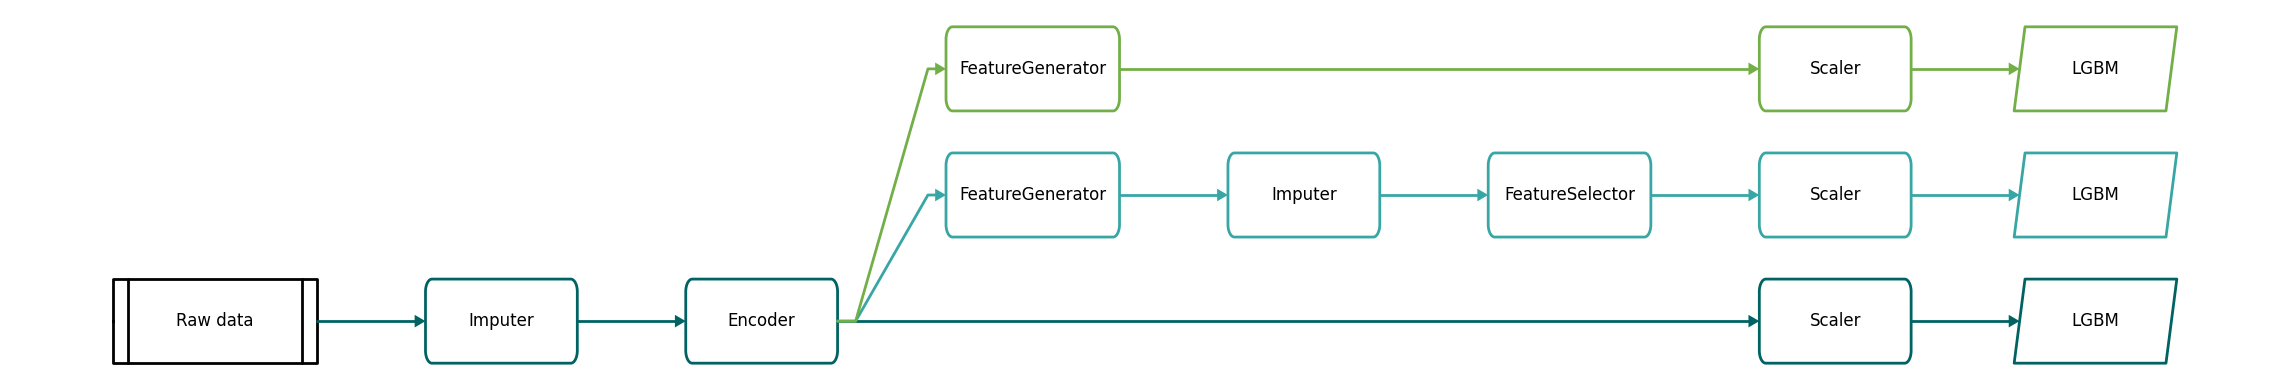

In [17]:
# Visualize o pipeline completo
experionml.plot_pipeline()

## Analisar os resultados

In [18]:
# Use os gráficos do experionml para comparar os três modelos
experionml.plot_roc(rows="test+train")

In [19]:
# Para comparar outros gráficos, pode ser útil usar um canvas
with experionml.canvas(1, 2, figsize=(1800, 800)):
    experionml.lgb_dfs.plot_roc(rows="test+train")
    experionml.lgb_dfs.plot_feature_importance(show=10, title="LGB + dfs")

In [20]:
# Também podemos verificar a importância das variáveis com outros gráficos
experionml.plot_permutation_importance(models=["LGB_dfs", "LGB_gfg"], show=12)

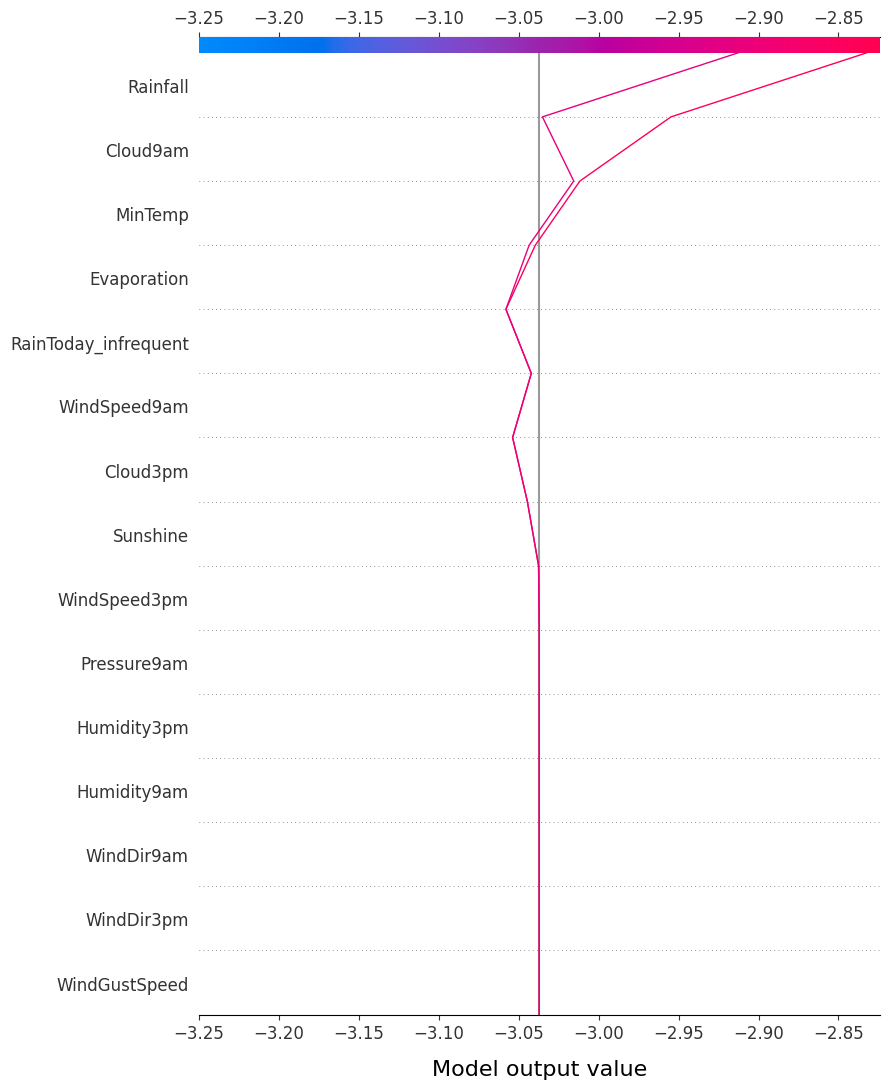

In [21]:
experionml.LGB_gfg.plot_shap_decision(rows=(0, 10), show=15)